In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("customer_analytics.csv")

In [5]:
#Phase1
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255 entries, 0 to 254
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   CustomerID            255 non-null    int64  
 1   Age                   255 non-null    int64  
 2   Gender                255 non-null    object 
 3   City                  255 non-null    object 
 4   Education             243 non-null    object 
 5   MaritalStatus         255 non-null    object 
 6   AnnualIncome          243 non-null    float64
 7   SpendingScore         255 non-null    int64  
 8   YearsEmployed         255 non-null    int64  
 9   PurchaseFrequency     255 non-null    int64  
 10  OnlineVisitsPerMonth  255 non-null    int64  
 11  ReturnedItems         255 non-null    int64  
 12  PreferredDevice       255 non-null    object 
 13  LastPurchaseAmount    255 non-null    int64  
dtypes: float64(1), int64(8), object(5)
memory usage: 28.0+ KB


,CustomerID,Age,AnnualIncome,SpendingScore,YearsEmployed,PurchaseFrequency,OnlineVisitsPerMonth,ReturnedItems,LastPurchaseAmount
count,255.000000,255.000000,243.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.00000
mean,1126.941176,37.729412,74499.901235,45.721569,14.682353,11.568627,16.078431,1.858824,2795.07451
std,72.397256,9.767842,43939.855655,17.869522,9.651664,7.077899,7.909536,1.409917,1328.77241
min,1001.000000,21.000000,16062.000000,5.000000,1.000000,1.000000,3.000000,0.000000,566.00000
25%,1064.500000,29.000000,56353.000000,34.500000,6.000000,5.000000,10.000000,1.000000,1542.50000
50%,1128.000000,38.000000,69629.000000,47.000000,15.000000,11.000000,16.000000,2.000000,2705.00000
75%,1190.500000,46.000000,84030.500000,57.500000,23.000000,18.000000,23.000000,3.000000,4001.00000
max,1250.000000,54.000000,474327.000000,95.000000,34.000000,24.000000,29.000000,4.000000,4996.00000


In [6]:
#Phase 2
df.isnull().sum()
(df.isnull().sum() / len(df)) * 100

CustomerID              0.000000
Age                     0.000000
Gender                  0.000000
City                    0.000000
Education               4.705882
MaritalStatus           0.000000
AnnualIncome            4.705882
SpendingScore           0.000000
YearsEmployed           0.000000
PurchaseFrequency       0.000000
OnlineVisitsPerMonth    0.000000
ReturnedItems           0.000000
PreferredDevice         0.000000
LastPurchaseAmount      0.000000
dtype: float64

In [10]:
df['Education'] = df['Education'].fillna(df['Education'].mode()[0])
df['AnnualIncome'] = df['AnnualIncome'].fillna(df['AnnualIncome'].mean())

In [13]:
df.duplicated().sum()
df = df.drop_duplicates()

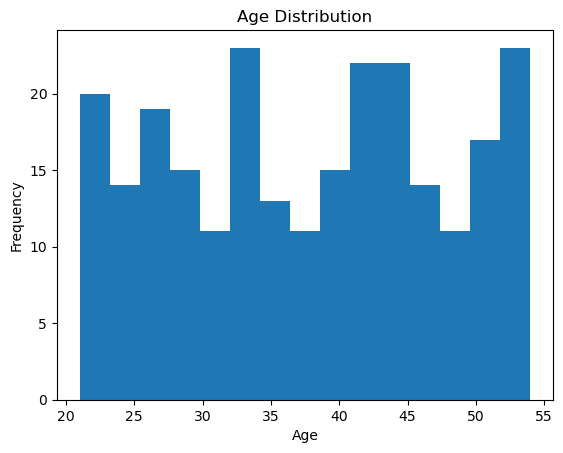

In [15]:
#Phase 3
plt.hist(df['Age'], bins=15)
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Age Distribution")
plt.show()

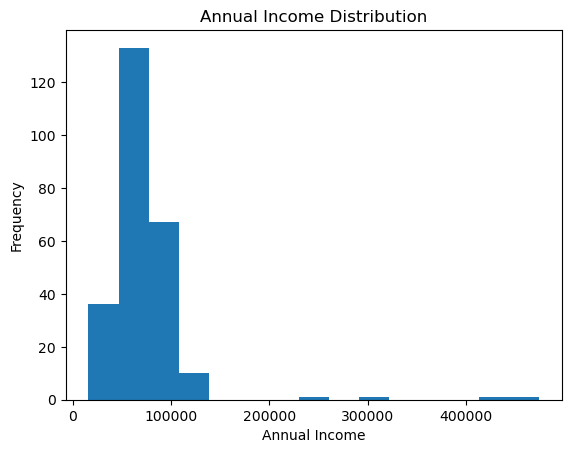

In [16]:
plt.hist(df['AnnualIncome'], bins=15)
plt.xlabel("Annual Income")
plt.ylabel("Frequency")
plt.title("Annual Income Distribution")
plt.show()

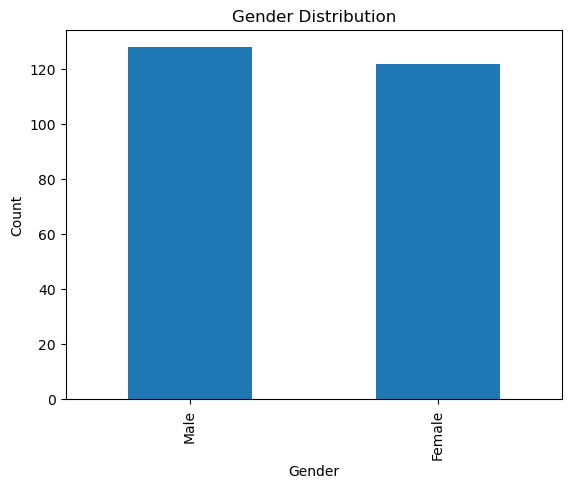

In [17]:
df['Gender'].value_counts().plot(kind='bar')
plt.xlabel("Gender")
plt.ylabel("Count")
plt.title("Gender Distribution")
plt.show()

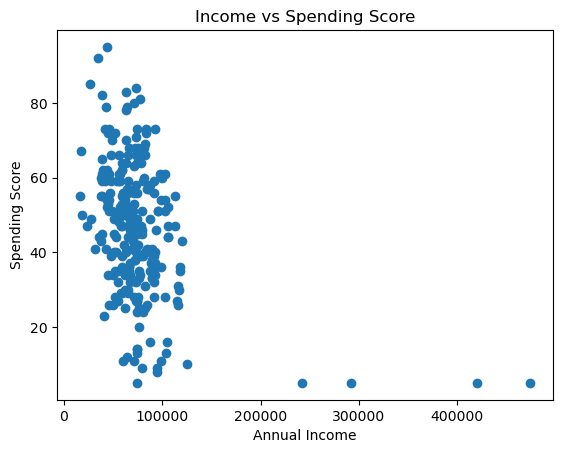

In [18]:
plt.scatter(df['AnnualIncome'], df['SpendingScore'])
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Income vs Spending Score")
plt.show()

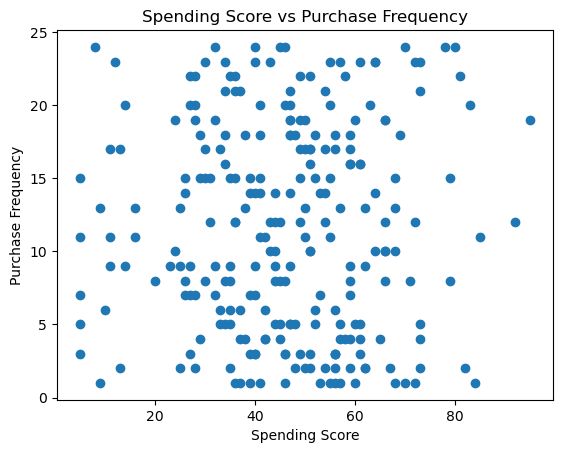

In [19]:
plt.scatter(df['SpendingScore'], df['PurchaseFrequency'])
plt.xlabel("Spending Score")
plt.ylabel("Purchase Frequency")
plt.title("Spending Score vs Purchase Frequency")
plt.show()

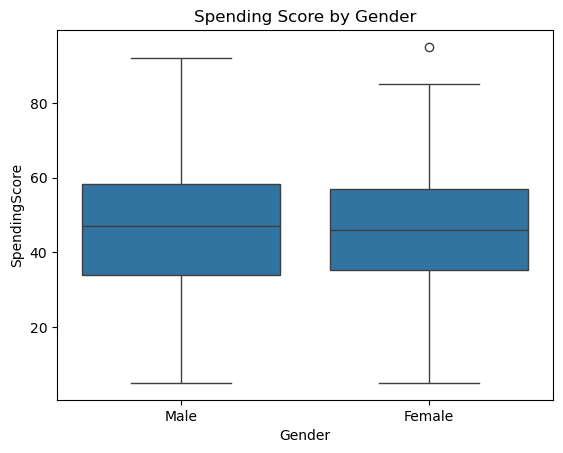

In [20]:
sns.boxplot(x='Gender', y='SpendingScore', data=df)
plt.title("Spending Score by Gender")
plt.show()

In [21]:
#Phase 4
df.corr(numeric_only=True)

,CustomerID,Age,AnnualIncome,SpendingScore,YearsEmployed,PurchaseFrequency,OnlineVisitsPerMonth,ReturnedItems,LastPurchaseAmount
CustomerID,1.000000,-0.038170,-0.039649,0.070869,-0.018877,-0.077040,-0.029642,0.023180,-0.034412
Age,-0.038170,1.000000,-0.051910,-0.006943,0.975242,0.103053,-0.033532,-0.051190,0.092891
AnnualIncome,-0.039649,-0.051910,1.000000,-0.386146,-0.054428,-0.037018,0.092756,-0.113211,-0.015953
SpendingScore,0.070869,-0.006943,-0.386146,1.000000,-0.017487,0.009792,-0.072441,0.057686,0.032737
YearsEmployed,-0.018877,0.975242,-0.054428,-0.017487,1.000000,0.073113,-0.052168,-0.050904,0.114464
PurchaseFrequency,-0.077040,0.103053,-0.037018,0.009792,0.073113,1.000000,-0.041362,0.084121,-0.068246
OnlineVisitsPerMonth,-0.029642,-0.033532,0.092756,-0.072441,-0.052168,-0.041362,1.000000,-0.071400,0.010528
ReturnedItems,0.023180,-0.051190,-0.113211,0.057686,-0.050904,0.084121,-0.071400,1.000000,0.016208
LastPurchaseAmount,-0.034412,0.092891,-0.015953,0.032737,0.114464,-0.068246,0.010528,0.016208,1.000000


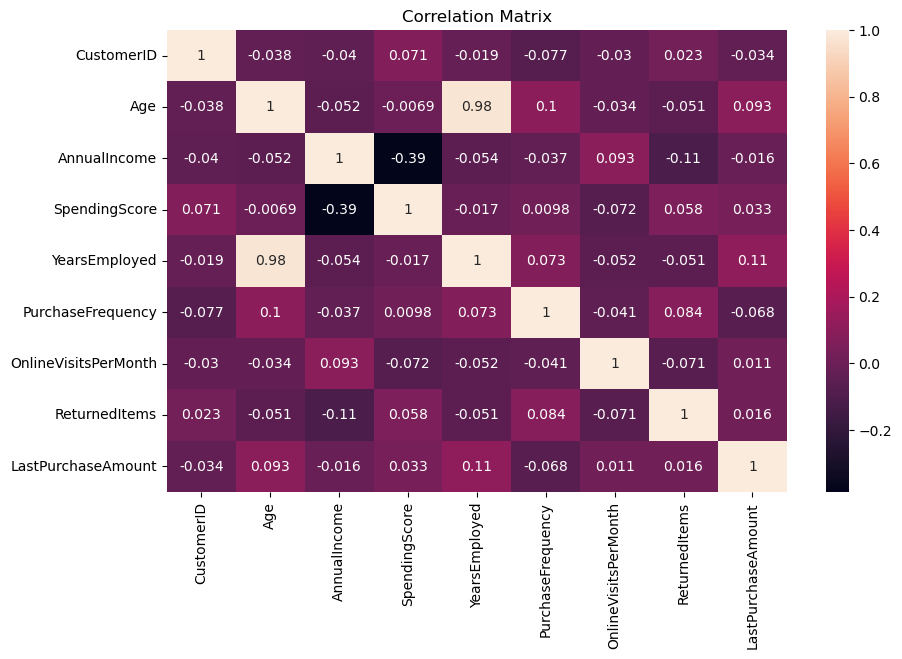

In [22]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Matrix")
plt.show()

In [26]:
from docx import Document
import pandas as pd
df = pd.read_csv("customer_analytics.csv")

In [28]:
!pip install reportlab

   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------- ----------------------------- 0.5/2.0 MB 8.5 MB/s eta 0:00:01
   ---------------------------------------- 2.0/2.0 MB 12.0 MB/s eta 0:00:00


In [12]:
# ==========================================
# MINI PROJECT EDA – ADVANCED REPORT VERSION
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Image, Preformatted
from reportlab.lib.pagesizes import A4
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle

plt.ioff()

# -------------------------------
# Load Dataset
# -------------------------------

df = pd.read_csv("customer_analytics.csv")

# -------------------------------
# Generate Charts
# -------------------------------

def save_plot(name):
    plt.savefig(name)
    plt.close()

plt.figure()
plt.hist(df['Age'], bins=20)
plt.title("Age Distribution")
save_plot("age.png")

plt.figure()
df['Gender'].value_counts().plot(kind='bar')
plt.title("Gender Count")
save_plot("gender.png")

plt.figure()
plt.hist(df['AnnualIncome'], bins=20)
plt.title("Income Distribution")
save_plot("income.png")

plt.figure()
plt.scatter(df['Age'], df['SpendingScore'])
plt.title("Age vs Spending Score")
save_plot("scatter.png")

plt.figure()
df.boxplot(column='AnnualIncome', by='Education')
plt.title("Income by Education Level")
plt.suptitle("")
save_plot("boxplot.png")

plt.figure()
corr = df.select_dtypes(include='number').corr()
plt.imshow(corr)
plt.colorbar()
plt.title("Correlation Matrix")
save_plot("correlation.png")

# -------------------------------
# Build PDF
# -------------------------------

styles = getSampleStyleSheet()
title = styles['Title']
heading = styles['Heading2']
normal = styles['BodyText']
code_style = ParagraphStyle('Code', fontName='Courier', fontSize=8)

pdf_name = "MiniProject_EDA_Report.pdf"

if os.path.exists(pdf_name):
    os.remove(pdf_name)

doc = SimpleDocTemplate(pdf_name, pagesize=A4)
elements = []

# Title
elements.append(Paragraph("Mini Project EDA Executive Report", title))
elements.append(Spacer(1, 12))

# Introduction
elements.append(Paragraph("Introduction", heading))
elements.append(Paragraph(
    "Exploratory Data Analysis (EDA) represents a foundational step in any "
    "data-driven analytical workflow. The objective of EDA is to examine raw "
    "datasets, understand structural characteristics, detect inconsistencies, "
    "and uncover patterns that may guide further modeling or decision-making.",
    normal
))

elements.append(Paragraph(
    "This report presents a comprehensive EDA of the Customer Analytics dataset. "
    "Each row corresponds to an individual customer record containing demographic "
    "information, socioeconomic attributes, and behavioral indicators. Through "
    "systematic inspection and visualization, the analysis aims to derive "
    "meaningful insights regarding customer characteristics and purchasing behavior.",
    normal
))

# Dataset Overview
elements.append(Paragraph("Dataset Overview", heading))
elements.append(Paragraph(
    f"The dataset contains <b>{df.shape[0]}</b> observations and <b>{df.shape[1]}</b> variables. "
    "The variables include both numerical and categorical features, enabling "
    "multi-dimensional analytical exploration.",
    normal
))

# Dataset Preview
elements.append(Paragraph("Dataset Preview", heading))
elements.append(Preformatted(str(df.head()), code_style))

# Statistical Summary
elements.append(Paragraph("Statistical Summary", heading))
elements.append(Paragraph(
    "Descriptive statistics provide a quantitative summary of dataset behavior. "
    "Measures such as mean, standard deviation, minimum, and maximum values "
    "help assess variability, central tendency, and dispersion across numerical features.",
    normal
))
elements.append(Preformatted(str(df.describe()), code_style))

# Helper
def add_chart(title_text, explanation, code_text, img_path, insight):
    elements.append(Paragraph(title_text, heading))
    elements.append(Paragraph(explanation, normal))
    elements.append(Paragraph("<b>Important Code Snippet</b>", normal))
    elements.append(Preformatted(code_text, code_style))
    elements.append(Image(img_path, width=400, height=200))
    elements.append(Paragraph("<b>Analytical Interpretation</b>", normal))
    elements.append(Paragraph(insight, normal))
    elements.append(Spacer(1, 12))

# Age
add_chart(
    "Age Distribution",
    "Age serves as a critical demographic variable influencing lifestyle, "
    "financial capacity, and consumer behavior. Understanding its distribution "
    "helps identify dominant customer segments.",
    "plt.hist(df['Age'], bins=20)",
    "age.png",
    "The histogram indicates that customers are concentrated within a central "
    "age band. This suggests the dataset primarily represents a specific "
    "demographic group rather than an evenly distributed population."
)

# Gender
add_chart(
    "Gender Distribution",
    "Gender segmentation is frequently used in market analytics. Examining its "
    "distribution ensures dataset balance and reduces bias in interpretation.",
    "df['Gender'].value_counts().plot(kind='bar')",
    "gender.png",
    "The chart illustrates the proportional representation of customers by gender. "
    "A balanced distribution improves analytical reliability and model stability."
)

# Income
add_chart(
    "Annual Income Distribution",
    "Annual Income is a major economic indicator affecting purchasing power, "
    "spending habits, and engagement levels.",
    "plt.hist(df['AnnualIncome'], bins=20)",
    "income.png",
    "Income values exhibit noticeable variability, suggesting diversity in "
    "customer financial capacity. The presence of higher-income observations "
    "may indicate premium customer segments."
)

# Scatter
add_chart(
    "Age vs Spending Score",
    "Bivariate analysis reveals relationships between demographic and behavioral "
    "features.",
    "plt.scatter(df['Age'], df['SpendingScore'])",
    "scatter.png",
    "The scatterplot suggests variability in spending behavior across age groups. "
    "Different age segments may display differing purchasing tendencies."
)

# Education
add_chart(
    "Income by Education Level",
    "Education level often correlates with earning potential and socioeconomic status.",
    "df.boxplot(column='AnnualIncome', by='Education')",
    "boxplot.png",
    "Income distributions vary across education categories, indicating potential "
    "socioeconomic stratification within the dataset."
)

# Correlation
add_chart(
    "Correlation Matrix",
    "Multivariate analysis examines interactions among multiple numerical variables.",
    "df.select_dtypes(include='number').corr()",
    "correlation.png",
    "Correlation patterns highlight relationships among features. Strong "
    "associations may indicate influential predictors for future modeling."
)

# Executive Summary
elements.append(Paragraph("Executive Summary", heading))
elements.append(Paragraph(
    "The Exploratory Data Analysis produced several important observations:",
    normal
))

elements.append(Paragraph(
    "• Customer demographics reveal structured variability rather than randomness.<br/>"
    "• Income levels exhibit dispersion, indicating diversity in purchasing capacity.<br/>"
    "• Spending behavior varies across demographic groups.<br/>"
    "• Feature interactions identified via correlation analysis support advanced modeling.<br/>"
    "• The dataset demonstrates sufficient structure for predictive or segmentation analysis.",
    normal
))

# Conclusion
elements.append(Paragraph("Conclusion", heading))
elements.append(Paragraph(
    "This Exploratory Data Analysis successfully transformed raw customer data "
    "into meaningful analytical insights. The study identified key demographic "
    "patterns, variability in socioeconomic indicators, and relationships among "
    "behavioral features.",
    normal
))

elements.append(Paragraph(
    "EDA plays a crucial role in validating dataset quality, guiding preprocessing "
    "strategies, and informing modeling decisions. The findings from this analysis "
    "suggest that the dataset is well-structured and suitable for advanced analytical "
    "tasks such as customer segmentation, predictive modeling, or behavioral forecasting.",
    normal
))

elements.append(Paragraph(
    "Overall, the analysis establishes a reliable foundation for future data-driven "
    "investigations and business decision-making.",
    normal
))

doc.build(elements)

print("\n🔥 ADVANCED PROFESSIONAL PDF GENERATED SUCCESSFULLY ✅")


🔍 DEBUGGING ENVIRONMENT
Current Folder: C:\Users\Punith Kumar

✅ Dataset Loaded Successfully

📊 GENERATING CHARTS
✅ Charts Generated Successfully

📝 BUILDING PDF REPORT

🔥 PDF GENERATED SUCCESSFULLY ✅
